In [1]:
import pandas as pd
df=pd.read_csv("diabetes_prediction_dataset.csv")
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [3]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [4]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [5]:
df.shape

(100000, 9)

In [6]:
df.duplicated().sum()

np.int64(3854)

In [7]:
df = df.drop_duplicates()

In [8]:
df.shape

(96146, 9)

In [9]:
import matplotlib.pyplot as plt

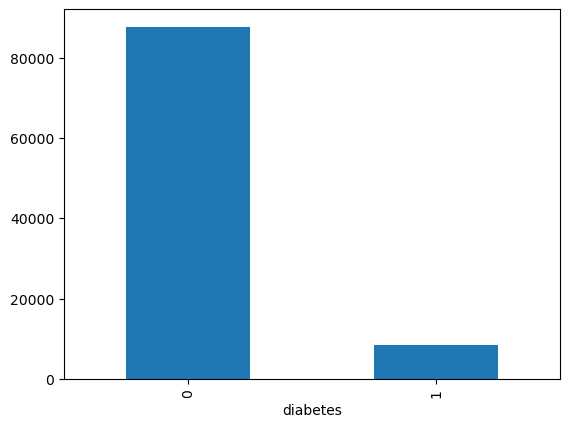

In [10]:
df["diabetes"].value_counts().plot(kind="bar")
plt.show()

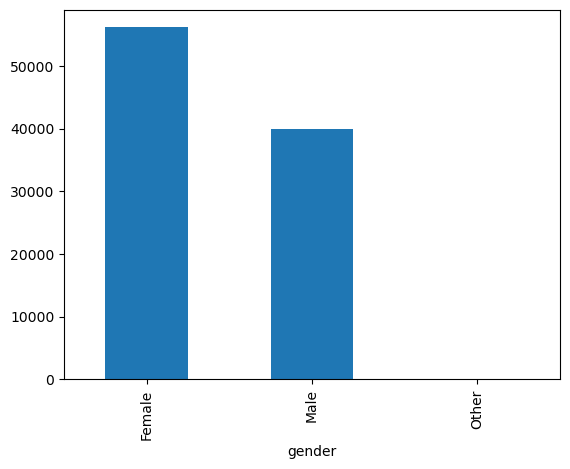

In [11]:
df["gender"].value_counts().plot(kind="bar")
plt.show()

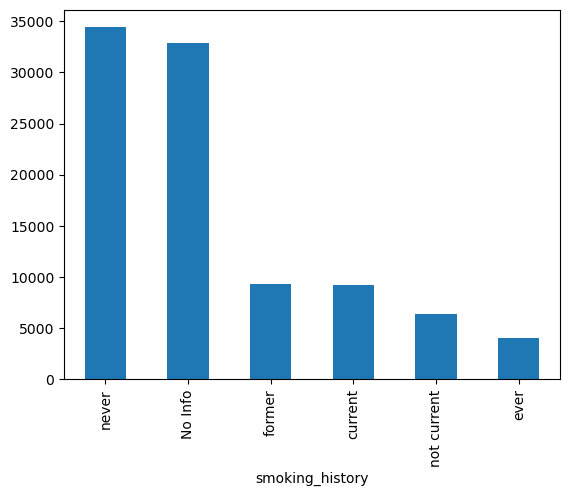

In [12]:
df["smoking_history"].value_counts().plot(kind="bar")
plt.show()

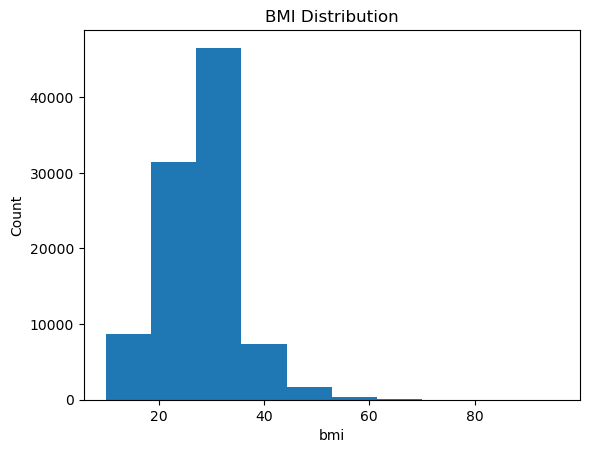

In [13]:
plt.hist(df["bmi"])
plt.xlabel("bmi")
plt.ylabel("Count")
plt.title("BMI Distribution")
plt.show()

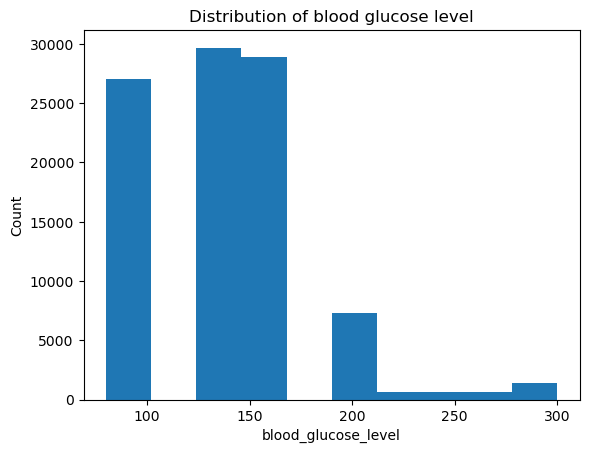

In [14]:
plt.hist(df["blood_glucose_level"])
plt.xlabel("blood_glucose_level")
plt.ylabel("Count")
plt.title("Distribution of blood glucose level")
plt.show()

In [15]:
pd.crosstab(
    df["gender"],
    df["diabetes"]
)

diabetes,0,1
gender,,
Female,51714,4447
Male,35932,4035
Other,18,0


In [16]:
pd.crosstab(
    df["smoking_history"],
    df["diabetes"]
)

diabetes,0,1
smoking_history,,
No Info,31442,1445
current,8249,948
ever,3526,472
former,7709,1590
never,31061,3337
not current,5677,690


In [17]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

In [18]:
numeric_df.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
0,80.0,0,1,25.19,6.6,140,0
1,54.0,0,0,27.32,6.6,80,0
2,28.0,0,0,27.32,5.7,158,0
3,36.0,0,0,23.45,5.0,155,0
4,76.0,1,1,20.14,4.8,155,0


In [19]:
numeric_df.corr()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
age,1.000000,0.257305,0.238451,0.344797,0.106719,0.114317,0.264927
hypertension,0.257305,1.000000,0.119982,0.148111,0.081441,0.084834,0.195710
heart_disease,0.238451,0.119982,1.000000,0.061376,0.068140,0.070832,0.170711
bmi,0.344797,0.148111,0.061376,1.000000,0.084423,0.092543,0.214932
HbA1c_level,0.106719,0.081441,0.068140,0.084423,1.000000,0.171615,0.406408
blood_glucose_level,0.114317,0.084834,0.070832,0.092543,0.171615,1.000000,0.424336
diabetes,0.264927,0.195710,0.170711,0.214932,0.406408,0.424336,1.000000


In [20]:
import seaborn as sns

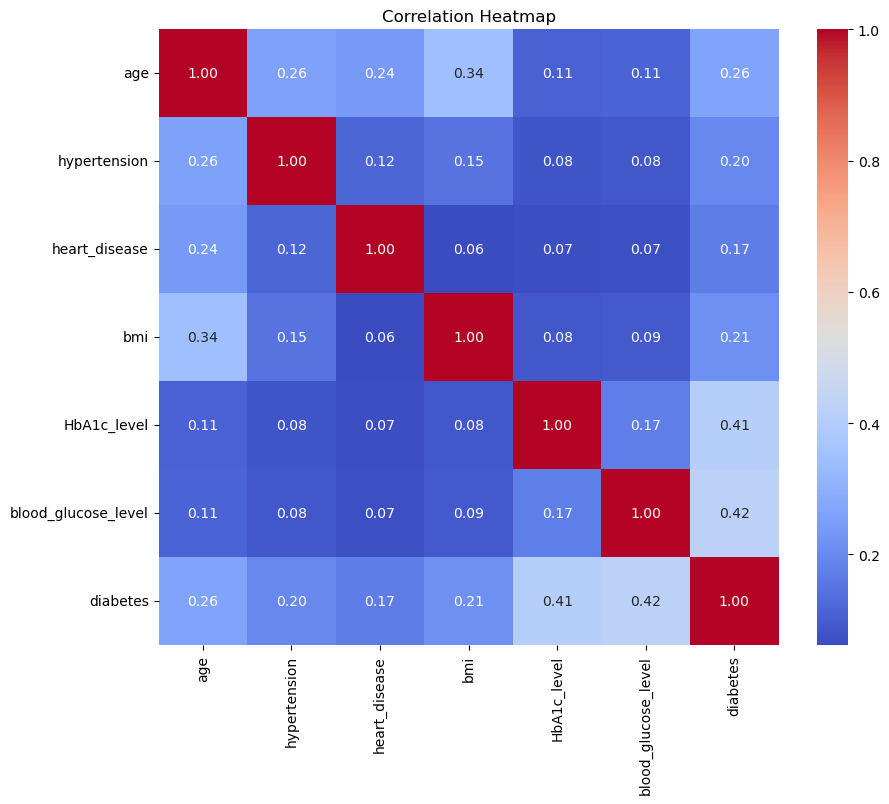

In [23]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10, 8))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

In [24]:
df["gender"].unique()

array(['Female', 'Male', 'Other'], dtype=object)

In [25]:
df["smoking_history"].unique()

array(['never', 'No Info', 'current', 'former', 'ever', 'not current'],
      dtype=object)

In [26]:
df = pd.get_dummies(
    df, columns=["gender", "smoking_history"],
    drop_first=True
)

In [27]:
df.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,False,False,False,False,False,True,False
1,54.0,0,0,27.32,6.6,80,0,False,False,False,False,False,False,False
2,28.0,0,0,27.32,5.7,158,0,True,False,False,False,False,True,False
3,36.0,0,0,23.45,5.0,155,0,False,False,True,False,False,False,False
4,76.0,1,1,20.14,4.8,155,0,True,False,True,False,False,False,False


In [28]:
y = df["diabetes"]

In [29]:
x = df.drop(
    "diabetes",
    axis=1
)

In [30]:
x.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,False,False,False,False,False,True,False
1,54.0,0,0,27.32,6.6,80,False,False,False,False,False,False,False
2,28.0,0,0,27.32,5.7,158,True,False,False,False,False,True,False
3,36.0,0,0,23.45,5.0,155,False,False,True,False,False,False,False
4,76.0,1,1,20.14,4.8,155,True,False,True,False,False,False,False


In [31]:
x.shape

(96146, 13)

In [32]:
y.shape

(96146,)

In [33]:
from sklearn.model_selection import train_test_split

In [34]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
from sklearn.preprocessing import StandardScaler

In [36]:
scaler = StandardScaler()

In [37]:
x_train=scaler.fit_transform(x_train)

In [38]:
x_test=scaler.transform(x_test)

In [39]:
x_train.view()

array([[-0.30198025, -0.2889759 , -0.20548047, ..., -0.32719332,
        -0.74495507, -0.26522469],
       [-1.84240507, -0.2889759 , -0.20548047, ..., -0.32719332,
        -0.74495507, -0.26522469],
       [ 0.81104346, -0.2889759 , -0.20548047, ..., -0.32719332,
        -0.74495507, -0.26522469],
       ...,
       [ 0.63295967,  3.46049617, -0.20548047, ..., -0.32719332,
         1.34236284, -0.26522469],
       [-0.21293836, -0.2889759 , -0.20548047, ..., -0.32719332,
         1.34236284, -0.26522469],
       [-0.2574593 , -0.2889759 , -0.20548047, ..., -0.32719332,
        -0.74495507, -0.26522469]], shape=(76916, 13))

In [40]:
from sklearn.linear_model import LogisticRegression

In [41]:
model = LogisticRegression()

In [42]:
model.fit(
    x_train,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [43]:
y_pred=model.predict(x_test)

In [44]:
y_pred

array([0, 0, 1, ..., 0, 0, 0], shape=(19230,))

In [45]:
y_test

2547     0
34774    0
71084    1
50584    0
80788    0
        ..
19314    0
17624    0
8673     0
37062    0
21353    0
Name: diabetes, Length: 19230, dtype: int64

In [46]:
comparision=pd.DataFrame({
    "Actual" : y_test,
    "Predicted" : y_pred
})

In [47]:
from sklearn.metrics import accuracy_score

In [48]:
print(
    accuracy_score(
        y_test,
        y_pred
    ) * 100
)

95.70982839313572
